SIMPLIFIED FAKEAV DETECTION SYSTEM
✅ GPU Available: Tesla T4

DATASET EXPLORATION
📂 Dataset Path: /kaggle/input/fakeav/FakeAVCeleb
📊 FakeVideo-FakeAudio: 10835 videos
📊 FakeVideo-RealAudio: 9709 videos
📊 RealVideo-RealAudio: 500 videos
📊 RealVideo-FakeAudio: 500 videos

📈 Total Videos: 21544

🎯 Sample Video Preview:
   📂 Class: FakeVideo-FakeAudio
   📹 File: 00037_id00680_wavtolip.mp4
   💾 Size: 0.2 MB


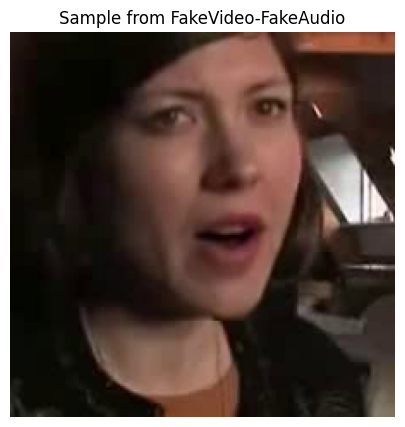


SETTING UP DIRECTORIES
✅ Audio directory: /kaggle/working/extracted_audio
✅ Features directory: /kaggle/working/cqt_features

EXTRACTING AUDIO

🎵 Processing FakeVideo-FakeAudio: 10835 videos


Extracting FakeVideo-FakeAudio: 100%|██████████| 10/10 [00:01<00:00,  6.47it/s]


✅ Extracted: 10 audio files

🎵 Processing FakeVideo-RealAudio: 9709 videos


Extracting FakeVideo-RealAudio: 100%|██████████| 10/10 [00:01<00:00,  8.45it/s]


✅ Extracted: 10 audio files

🎵 Processing RealVideo-RealAudio: 500 videos


...

Train Acc: 37.50% | Val Acc: 0.00%

Epoch 4/5


Validation: 100%|██████████| 1/1 [00:00<00:00,  5.66it/s]


Train Acc: 40.62% | Val Acc: 37.50%

Epoch 5/5


Validation: 100%|██████████| 1/1 [00:00<00:00,  5.62it/s]


Train Acc: 71.88% | Val Acc: 50.00%
✅ New best model saved: 50.00%


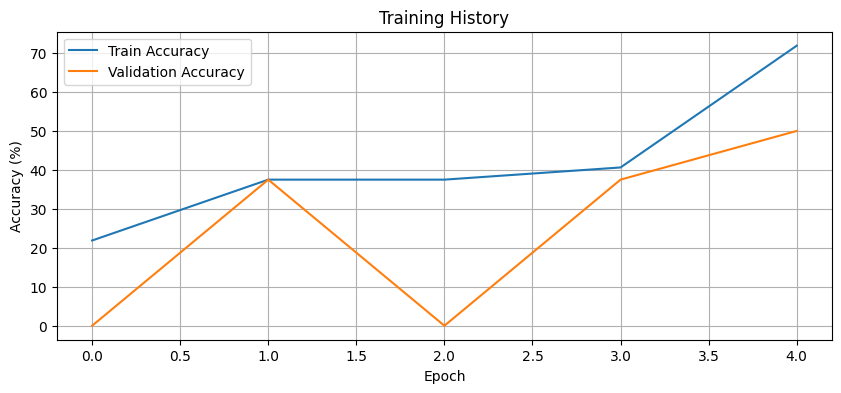


✅ Training completed!
💾 Model saved: /kaggle/working/fakeav_model.pth
🎯 Best accuracy: 50.00%

FAKEAV DETECTION SYSTEM READY!
📋 Summary:
• Dataset explored: 21544 videos
• Audio extracted: 40 files
• CQT features: 40 images
• Model saved: True


In [2]:
import os
import sys
import shutil
import random
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Deep Learning Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
import torch.nn.functional as F

# Audio Processing Libraries
import librosa
import librosa.display
import subprocess
from PIL import Image
import cv2

# Machine Learning Libraries
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Suppress warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("=" * 80)
print("SIMPLIFIED FAKEAV DETECTION SYSTEM")
print("=" * 80)

# ============================================================================
# STEP 1: SETUP AND GPU CHECK
# ============================================================================

def check_gpu():
    """Check if GPU is available"""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"✅ GPU Available: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device('cpu')
        print("⚠️ GPU not available, using CPU")
    return device

device = check_gpu()

# ============================================================================
# STEP 2: PATHS AND DATASET EXPLORATION
# ============================================================================

# Define paths
INPUT_BASE = Path("/kaggle/input/fakeav/FakeAVCeleb")
OUTPUT_BASE = Path("/kaggle/working/extracted_audio")
FEATURES_BASE = Path("/kaggle/working/cqt_features")
MODEL_SAVE_PATH = Path("/kaggle/working/fakeav_model.pth")

# Define classes
CLASSES = [
    'FakeVideo-FakeAudio',
    'FakeVideo-RealAudio', 
    'RealVideo-RealAudio',
    'RealVideo-FakeAudio'
]

def explore_dataset():
    """Simple dataset exploration"""
    print("\n" + "="*60)
    print("DATASET EXPLORATION")
    print("="*60)
    
    if not INPUT_BASE.exists():
        print(f"❌ Dataset not found: {INPUT_BASE}")
        return None
    
    print(f"📂 Dataset Path: {INPUT_BASE}")
    
    dataset_info = {}
    total_videos = 0
    
    # Check each class directory
    for class_name in CLASSES:
        class_path = INPUT_BASE / class_name
        video_files = []
        
        if class_path.exists():
            # Find video files
            for ext in ['*.mp4', '*.avi', '*.mov']:
                video_files.extend(list(class_path.glob(ext)))
                # Check subdirectories too
                video_files.extend(list(class_path.rglob(ext)))
            
            # Remove duplicates
            video_files = list(set(video_files))
            dataset_info[class_name] = video_files
            total_videos += len(video_files)
            
            print(f"📊 {class_name}: {len(video_files)} videos")
        else:
            print(f"❌ Not found: {class_name}")
            dataset_info[class_name] = []
    
    print(f"\n📈 Total Videos: {total_videos}")
    
    # Show a sample video if available
    if total_videos > 0:
        print("\n🎯 Sample Video Preview:")
        
        # Find first available video
        sample_video = None
        sample_class = None
        for class_name, videos in dataset_info.items():
            if videos:
                sample_video = videos[0]
                sample_class = class_name
                break
        
        if sample_video:
            try:
                file_size = sample_video.stat().st_size / (1024*1024)
                print(f"   📂 Class: {sample_class}")
                print(f"   📹 File: {sample_video.name}")
                print(f"   💾 Size: {file_size:.1f} MB")
                
                # Show first frame
                cap = cv2.VideoCapture(str(sample_video))
                if cap.isOpened():
                    ret, frame = cap.read()
                    if ret:
                        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                        plt.figure(figsize=(8, 5))
                        plt.imshow(frame_rgb)
                        plt.title(f'Sample from {sample_class}')
                        plt.axis('off')
                        plt.show()
                    cap.release()
            except Exception as e:
                print(f"   ⚠️ Error: {e}")
    
    return dataset_info

# Run exploration
dataset_info = explore_dataset()

# ============================================================================
# STEP 3: SETUP DIRECTORIES
# ============================================================================

def setup_directories():
    """Create output directories"""
    print("\n" + "="*60)
    print("SETTING UP DIRECTORIES")
    print("="*60)
    
    # Clean existing directories
    for path in [OUTPUT_BASE, FEATURES_BASE]:
        if path.exists():
            shutil.rmtree(path)
        path.mkdir(parents=True, exist_ok=True)
    
    # Create class subdirectories
    for class_name in CLASSES:
        (OUTPUT_BASE / class_name).mkdir(exist_ok=True)
        (FEATURES_BASE / class_name).mkdir(exist_ok=True)
    
    print(f"✅ Audio directory: {OUTPUT_BASE}")
    print(f"✅ Features directory: {FEATURES_BASE}")

setup_directories()

# ============================================================================
# STEP 4: AUDIO EXTRACTION
# ============================================================================

def extract_audio(video_path, audio_path):
    """Extract audio from video using ffmpeg"""
    try:
        cmd = [
            'ffmpeg', '-i', str(video_path),
            '-vn', '-acodec', 'pcm_s16le', '-ar', '22050', '-ac', '1',
            str(audio_path), '-y', '-loglevel', 'quiet'
        ]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_all_audio():
    """Extract audio from all videos"""
    print("\n" + "="*60)
    print("EXTRACTING AUDIO")
    print("="*60)
    
    if not dataset_info:
        print("❌ No dataset info available")
        return
    
    extraction_stats = {}
    
    for class_name in CLASSES:
        videos = dataset_info.get(class_name, [])
        if not videos:
            continue
        
        print(f"\n🎵 Processing {class_name}: {len(videos)} videos")
        
        success_count = 0
        output_dir = OUTPUT_BASE / class_name
        
        for video_file in tqdm(videos[:10], desc=f"Extracting {class_name}"):  # Limit to 10 per class
            audio_file = output_dir / f"{video_file.stem}.wav"
            if extract_audio(video_file, audio_file):
                success_count += 1
        
        extraction_stats[class_name] = success_count
        print(f"✅ Extracted: {success_count} audio files")
    
    return extraction_stats

# Extract audio
audio_stats = extract_all_audio()

# ============================================================================
# STEP 5: CQT FEATURE EXTRACTION
# ============================================================================

def create_cqt_image(audio_path, output_path):
    """Create CQT spectrogram image from audio"""
    try:
        # Load audio (first 10 seconds)
        y, sr = librosa.load(audio_path, sr=22050, duration=10.0)
        
        # Compute CQT
        cqt = librosa.cqt(y, sr=sr, hop_length=512, n_bins=84)
        cqt_db = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)
        
        # Create image
        plt.figure(figsize=(10, 6))
        librosa.display.specshow(cqt_db, sr=sr, x_axis='time', y_axis='cqt_note')
        plt.axis('off')
        plt.tight_layout(pad=0)
        plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=150)
        plt.close()
        
        return True
    except:
        return False

def extract_cqt_features():
    """Extract CQT features from all audio files"""
    print("\n" + "="*60)
    print("EXTRACTING CQT FEATURES")
    print("="*60)
    
    feature_stats = {}
    
    for class_name in CLASSES:
        audio_dir = OUTPUT_BASE / class_name
        feature_dir = FEATURES_BASE / class_name
        
        if not audio_dir.exists():
            continue
        
        audio_files = list(audio_dir.glob("*.wav"))
        if not audio_files:
            continue
        
        print(f"\n🎵 Processing {class_name}: {len(audio_files)} audio files")
        
        success_count = 0
        for audio_file in tqdm(audio_files, desc=f"CQT {class_name}"):
            cqt_file = feature_dir / f"{audio_file.stem}.jpg"
            if create_cqt_image(audio_file, cqt_file):
                success_count += 1
        
        feature_stats[class_name] = success_count
        print(f"✅ Created: {success_count} CQT images")
    
    return feature_stats

# Extract CQT features
cqt_stats = extract_cqt_features()

# ============================================================================
# STEP 6: DATASET CLASS
# ============================================================================

class SimpleDataset(Dataset):
    """Simple dataset for CQT images"""
    
    def __init__(self, features_base, classes, transform=None):
        self.features_base = features_base
        self.classes = classes
        self.class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
        self.transform = transform
        self.samples = []
        
        # Collect all samples
        for class_name in classes:
            class_path = features_base / class_name
            if class_path.exists():
                for img_file in class_path.glob("*.jpg"):
                    self.samples.append((str(img_file), self.class_to_idx[class_name]))
        
        print(f"📊 Dataset: {len(self.samples)} samples")
        for i, class_name in enumerate(classes):
            count = sum(1 for _, label in self.samples if label == i)
            print(f"   {class_name}: {count}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# ============================================================================
# STEP 7: MODEL DEFINITION
# ============================================================================

class SimpleFakeAVModel(nn.Module):
    """Simple Vision Transformer for FakeAV detection"""
    
    def __init__(self, num_classes=4):
        super().__init__()
        
        # Load pretrained ViT
        self.vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        
        # Replace classifier
        self.vit.heads.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.vit.heads.head.in_features, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.vit(x)

# ============================================================================
# STEP 8: TRAINING SETUP
# ============================================================================

def create_data_loaders():
    """Create train and validation loaders"""
    print("\n" + "="*60)
    print("CREATING DATA LOADERS")
    print("="*60)
    
    # Define transforms
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # Create dataset
    full_dataset = SimpleDataset(FEATURES_BASE, CLASSES, train_transform)
    
    if len(full_dataset) == 0:
        print("❌ No samples found!")
        return None, None
    
    # Split dataset
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    
    # Create loaders
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
    
    print(f"✅ Train samples: {len(train_dataset)}")
    print(f"✅ Val samples: {len(val_dataset)}")
    
    return train_loader, val_loader

# Create data loaders
train_loader, val_loader = create_data_loaders()

# ============================================================================
# STEP 9: TRAINING FUNCTION
# ============================================================================

def train_model(model, train_loader, val_loader, epochs=10):
    """Simple training function"""
    if train_loader is None:
        print("❌ No training data available")
        return None
    
    print("\n" + "="*60)
    print("TRAINING MODEL")
    print("="*60)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    
    best_acc = 0.0
    history = {'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        # Training
        model.train()
        train_correct = 0
        train_total = 0
        
        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        train_acc = 100. * train_correct / train_total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = 100. * val_correct / val_total
        
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'classes': CLASSES,
                'accuracy': best_acc
            }, MODEL_SAVE_PATH)
            print(f"✅ New best model saved: {best_acc:.2f}%")
    
    return model, history

# ============================================================================
# STEP 10: MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""
    print("\n" + "="*80)
    print("STARTING TRAINING PIPELINE")
    print("="*80)
    
    if train_loader is None:
        print("❌ Cannot proceed without training data")
        return
    
    # Initialize model
    model = SimpleFakeAVModel(num_classes=len(CLASSES))
    model = model.to(device)
    
    print(f"🤖 Model loaded on: {device}")
    
    # Train model
    trained_model, history = train_model(model, train_loader, val_loader, epochs=5)
    
    if trained_model and history:
        # Plot training history
        plt.figure(figsize=(10, 4))
        plt.plot(history['train_acc'], label='Train Accuracy')
        plt.plot(history['val_acc'], label='Validation Accuracy')
        plt.title('Training History')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.grid()
        plt.show()
        
        print(f"\n✅ Training completed!")
        print(f"💾 Model saved: {MODEL_SAVE_PATH}")
        print(f"🎯 Best accuracy: {max(history['val_acc']):.2f}%")

# Run main function
if __name__ == "__main__":
    main()
    
    print("\n" + "="*80)
    print("FAKEAV DETECTION SYSTEM READY!")
    print("="*80)
    print("📋 Summary:")
    print(f"• Dataset explored: {sum(len(v) for v in dataset_info.values()) if dataset_info else 0} videos")
    print(f"• Audio extracted: {sum(audio_stats.values()) if audio_stats else 0} files")  
    print(f"• CQT features: {sum(cqt_stats.values()) if cqt_stats else 0} images")
    print(f"• Model saved: {MODEL_SAVE_PATH.exists()}")
    print("="*80)